# Task 0 · Gradient boosting baseline

The team's reference model, built on the shared benchmark in [`forecast/`](forecast/). See [`TASK0_README.md`](TASK0_README.md) for the rules and the evaluation.

- **Day-ahead rule:** the forecast for day D is made at the end of day D-1. It uses load and weather up to D-1, nothing from day D.
- **Data processing choice:** `Config(weather_resampling=...)` sets how hourly weather becomes 15-min values, `"step"` or `"interpolate"`.
- **Output:** `evaluate.evaluate` prints the scores of this run: **MAE** and **RMSE** in kWh, and **R²**. Nothing is written to the leaderboard; to add a run there, call `evaluate.submit(...)` (see section 3). The leaderboard itself keeps ranking by nMAE (MAE as % of mean consumption).

**Units of MAE / RMSE:** they are in kWh of each level: per household and 15 min, per household and day, for the whole portfolio per 15 min, or for the whole portfolio per day. Compare them within a level, not across levels.

Runtime ≈ 3 min (the first run also builds `cache/`), peak memory ≈ 6 GB.

In [25]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

from forecast import Config, baselines, data, evaluate, features

config = Config(weather_resampling="step")  # "step" or "interpolate"
NAME = f"gbm_{config.weather_resampling}"  # label of this run (and its name if you submit it)
AUTHOR = "pengxuanHuang"
MODEL_PARAMS = dict(max_iter=300, learning_rate=0.1, categorical_features="from_dtype", random_state=0)
METRICS = ["MAE", "RMSE", "R2"]  # shown in this notebook; MAE / RMSE in kWh of each level

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Standard features

In [26]:
df, valid_household_list = features.build_features(config)
FEATURES = features.standard_features()
train, test = features.split(df, config)
print(f"{len(FEATURES)} features · train sample {len(train):,} rows · test {len(test):,} rows")
FEATURES

26 features · train sample 3,000,000 rows · test 12,471,135 rows


['temperature_1d',
 'temperature_day_mean_1d',
 'sunshine_1d',
 'humidity_1d',
 'wind_speed_1d',
 'sunshine_filled_1d',
 'quarter_hour',
 'weekday',
 'month',
 'kwh_lag_1d',
 'kwh_lag_7d',
 'is_treatment',
 'after_visit',
 'has_pv',
 'Survey_Building_LivingArea',
 'Survey_Building_Residents',
 'Survey_Building_Type',
 'Survey_HeatPump_Installation_Type',
 'Survey_HeatDistribution_System_FloorHeating',
 'Survey_HeatDistribution_System_Radiator',
 'Survey_DHW_Production_ByHeatPump',
 'Survey_DHW_Production_ByElectricWaterHeater',
 'Survey_DHW_Production_BySolar',
 'Survey_Installation_HasDryer',
 'Survey_Installation_HasFreezer',
 'Survey_Installation_HasElectricVehicle']

In [27]:
len(valid_household_list)

375





\\\\## 3. Predict and evaluate

`evaluate.evaluate` scores every test row with the standard evaluation and only prints the result. To put a run on the shared leaderboard, uncomment the `evaluate.submit` line.

## 2. Train

In [28]:
model = HistGradientBoostingRegressor(**MODEL_PARAMS)
model.fit(train[FEATURES], train["kwh"])

HistGradientBoostingRegressor(max_iter=300, random_state=0)

## 3. Predict and evaluate

`evaluate.evaluate` scores every test row with the standard evaluation and only prints the result. To put a run on the shared leaderboard, uncomment the `evaluate.submit` line.

In [29]:
predictions = test[["Household_ID", "Timestamp"]].assign(prediction=model.predict(test[FEATURES]).clip(min=0))
print(f"{NAME}: MAE / RMSE (kWh) and R² per level")
display(evaluate.evaluate(predictions)[METRICS].round(3))

# evaluate.submit(predictions, NAME, AUTHOR,
#                 description=f"HistGradientBoosting, standard features, weather {config.weather_resampling}",
#                 config=config.to_dict(), params=MODEL_PARAMS)

gbm_step: MAE / RMSE (kWh) and R² per level


,MAE,RMSE,R2
portfolio_15min,11.654,16.466,0.904
portfolio_day,752.471,1113.287,0.942
household_15min,0.175,0.287,0.416
household_day,5.792,8.902,0.819


# 3.1 Validation to optimize the hyperparameters of HGB

**Holdout:** the hyperparameters are compared on the **last two months before the test year** (2023-01-01 → 2023-02-28), training only on data before 2023-01-01 (a random 1M-row sample, to keep it fast). The test year itself is never used for tuning: otherwise the test score would be optimistic and no longer comparable with the leaderboard.

**Decision metric:** validation **portfolio MAE per 15 min** (kWh). On one fixed validation set this ranks candidates exactly like the leaderboard's nMAE. The current `MODEL_PARAMS` are always one of the candidates, so the chosen set is at least as good on the holdout. The winner is then retrained on the full training data (3M rows before the test year) and scored on the test year next to the untuned model.

In [30]:
from forecast import tuning

N_CANDIDATES = 12  # random parameter sets to try (plus the current MODEL_PARAMS); ≈ 15 s each

fit_rows, val_rows = tuning.holdout_split(df, config, start="2023-01-01", sample=1_000_000)
val_days = val_rows["Timestamp"].dt.tz_convert("Europe/Berlin")
print(f"fit {len(fit_rows):,} rows before 2023-01-01 · validate {len(val_rows):,} rows "
      f"({val_days.min():%Y-%m-%d} → {val_days.max():%Y-%m-%d})")

candidates = tuning.random_candidates(N_CANDIDATES, seed=0, base=MODEL_PARAMS)
results = tuning.tune(fit_rows, val_rows, candidates, FEATURES)
params_table = pd.json_normalize(results["params"]).drop(columns=["categorical_features", "random_state"], errors="ignore")
pd.concat([results.drop(columns="params"), params_table], axis=1).round(3)

fit 1,000,000 rows before 2023-01-01 · validate 1,855,136 rows (2023-01-01 → 2023-02-28)
candidate  0: portfolio 15-min MAE 16.34 kWh (12.9 s)
candidate  1: portfolio 15-min MAE 17.38 kWh (22.8 s)
candidate  2: portfolio 15-min MAE 17.26 kWh (9.8 s)
candidate  3: portfolio 15-min MAE 17.12 kWh (144.7 s)
candidate  4: portfolio 15-min MAE 16.72 kWh (37.7 s)
candidate  5: portfolio 15-min MAE 16.46 kWh (128.9 s)
candidate  6: portfolio 15-min MAE 16.34 kWh (16.3 s)
candidate  7: portfolio 15-min MAE 16.19 kWh (10.2 s)
candidate  8: portfolio 15-min MAE 16.53 kWh (269.3 s)
candidate  9: portfolio 15-min MAE 16.85 kWh (10.6 s)
candidate 10: portfolio 15-min MAE 16.44 kWh (33.0 s)
candidate 11: portfolio 15-min MAE 17.19 kWh (22.7 s)
candidate 12: portfolio 15-min MAE 17.07 kWh (28.1 s)


,candidate,portfolio_15min_MAE,portfolio_15min_RMSE,portfolio_15min_R2,portfolio_day_MAE,household_15min_R2,fit_seconds,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,early_stopping
0,7,16.195,20.463,0.744,1134.364,0.371,10.2,0.20,200,31,500,0.0,False
1,0,16.340,20.641,0.740,1113.897,0.372,12.9,0.10,300,31,20,0.0,auto
2,6,16.344,20.583,0.741,1186.939,0.373,16.3,0.20,400,31,500,1.0,False
3,10,16.438,20.711,0.738,1176.356,0.374,33.0,0.10,400,127,20,0.1,False
4,5,16.460,20.885,0.734,1176.858,0.377,128.9,0.05,800,127,20,0.1,False
5,8,16.526,20.836,0.735,1160.184,0.375,269.3,0.10,200,63,100,0.1,False
6,4,16.720,21.048,0.730,1203.726,0.376,37.7,0.10,400,127,100,1.0,False
7,9,16.846,21.345,0.722,1121.467,0.362,10.6,0.05,200,31,20,0.0,False
8,12,17.075,21.763,0.711,1185.946,0.364,28.1,0.20,400,127,500,0.1,False
9,3,17.125,21.513,0.718,1243.968,0.371,144.7,0.10,800,127,100,1.0,False


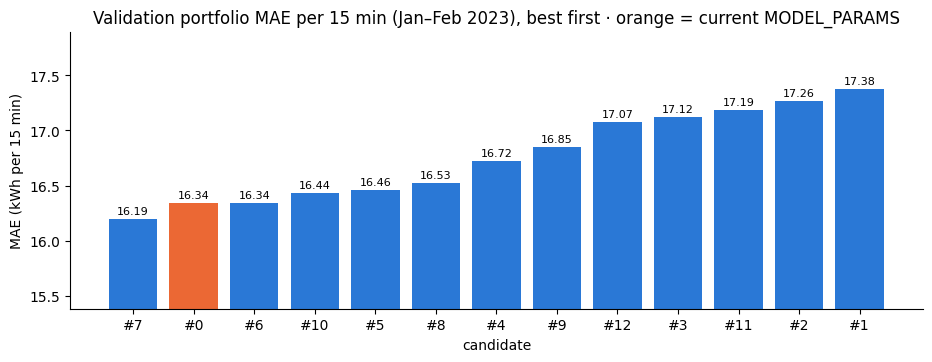

In [31]:
# Validation score per candidate (lower is better); the current MODEL_PARAMS are candidate 0
x = np.arange(len(results))
fig, ax = plt.subplots(figsize=(11, 3.6))
bars = ax.bar(x, results["portfolio_15min_MAE"],
              color=np.where(results["candidate"] == 0, "#eb6834", "#2a78d6"))
ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
ax.set_xticks(x, [f"#{c}" for c in results["candidate"]])
ax.set(title="Validation portfolio MAE per 15 min (Jan–Feb 2023), best first · orange = current MODEL_PARAMS",
       xlabel="candidate", ylabel="MAE (kWh per 15 min)",
       ylim=(results["portfolio_15min_MAE"].min() * 0.95, results["portfolio_15min_MAE"].max() * 1.03))
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [32]:
# Retrain the best candidate on the full training data and score it on the test year
BEST_PARAMS = results.loc[0, "params"]
print("best parameters:", {k: v for k, v in BEST_PARAMS.items() if k not in ("categorical_features", "random_state")})

model_tuned = HistGradientBoostingRegressor(**BEST_PARAMS).fit(train[FEATURES], train["kwh"])
predictions_tuned = test[["Household_ID", "Timestamp"]].assign(
    prediction=model_tuned.predict(test[FEATURES]).clip(min=0))

pd.concat({NAME: evaluate.evaluate(predictions)[METRICS],
           f"{NAME}_tuned": evaluate.evaluate(predictions_tuned)[METRICS]}, axis=1).round(3)

# evaluate.submit(predictions_tuned, f"{NAME}_tuned", AUTHOR,
#                 description="HistGradientBoosting tuned on Jan-Feb 2023 holdout, standard features",
#                 config=config.to_dict(), params=BEST_PARAMS)

best parameters: {'learning_rate': 0.2, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 500, 'l2_regularization': 0.0, 'early_stopping': False}


gbm_step                  gbm_step_tuned                 
                     MAE      RMSE     R2            MAE      RMSE     R2
portfolio_15min   11.654    16.466  0.904         11.561    16.342  0.905
portfolio_day    752.471  1113.287  0.942        746.181  1100.992  0.944
household_15min    0.175     0.287  0.416          0.175     0.286  0.418
household_day      5.792     8.902  0.819          5.793     8.906  0.819

## 4. Reference baselines

Naive forecasts every model should beat, scored the same way (printed only).

**Portfolio** measures all homes added together
**Household**: measure each home on its own

In [33]:
# All forecasts of this run, used by the comparisons below
runs = {
    NAME: predictions,
    f"{NAME}_tuned": predictions_tuned,                 # best parameters from 3.1
    "naive_lag_1d": baselines.naive(df, "kwh_lag_1d"),  # same 15 min yesterday
    "naive_lag_7d": baselines.naive(df, "kwh_lag_7d"),  # same 15 min one week ago
}
scores = {name: evaluate.evaluate(p)[METRICS] for name, p in runs.items()}
for name in ("naive_lag_1d", "naive_lag_7d"):
    print(f"{name}: MAE / RMSE (kWh) and R² per level")
    display(scores[name].round(3))

naive_lag_1d: MAE / RMSE (kWh) and R² per level


,MAE,RMSE,R2
portfolio_15min,13.462,19.246,0.869
portfolio_day,760.878,1148.258,0.939
household_15min,0.194,0.371,0.024
household_day,5.476,9.234,0.806


naive_lag_7d: MAE / RMSE (kWh) and R² per level


,MAE,RMSE,R2
portfolio_15min,20.529,30.043,0.680
portfolio_day,1628.862,2459.917,0.718
household_15min,0.205,0.380,-0.027
household_day,7.871,12.724,0.631


## 5. Comparison of this run

Side by side, and the daily portfolio energy over the test winter. `evaluate.leaderboard()` still shows the shared leaderboard (submitted runs only).

In [34]:
pd.concat({name: s.stack() for name, s in scores.items()}, axis=1).T.round(3)

portfolio_15min                portfolio_day                   \
                           MAE    RMSE     R2           MAE      RMSE     R2   
gbm_step                11.654  16.466  0.904       752.471  1113.287  0.942   
gbm_step_tuned          11.561  16.342  0.905       746.181  1100.992  0.944   
naive_lag_1d            13.462  19.246  0.869       760.878  1148.258  0.939   
naive_lag_7d            20.529  30.043  0.680      1628.862  2459.917  0.718   

               household_15min               household_day                 
                           MAE   RMSE     R2           MAE    RMSE     R2  
gbm_step                 0.175  0.287  0.416         5.792   8.902  0.819  
gbm_step_tuned           0.175  0.286  0.418         5.793   8.906  0.819  
naive_lag_1d             0.194  0.371  0.024         5.476   9.234  0.806  
naive_lag_7d             0.205  0.380 -0.027         7.871  12.724  0.631

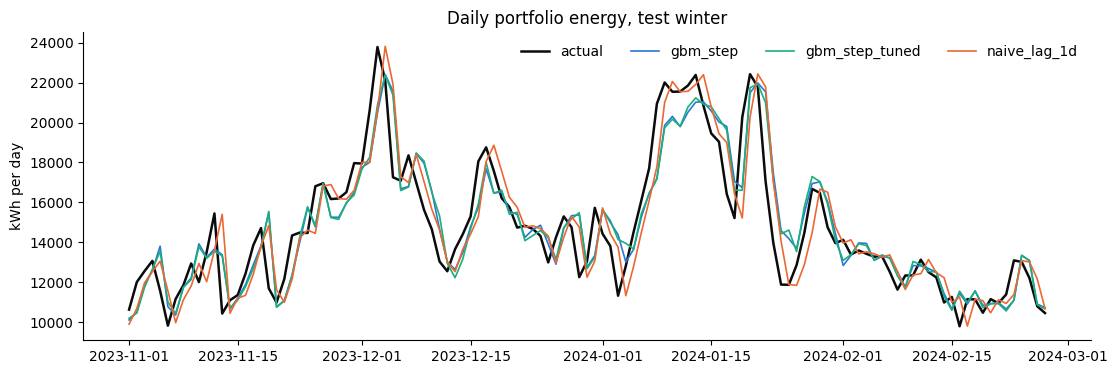

In [35]:
truth = data.ground_truth()
COLORS = ["#2a78d6", "#1baf7a", "#eb6834", "#eda100"]  # one per entry in `runs`, same order

# Daily portfolio energy: actual vs the forecasts of this run (partial last test day left out)
day = truth["Timestamp"].dt.tz_convert("Europe/Berlin").dt.date
daily = pd.DataFrame({"actual": truth["kwh"].groupby(day).sum()})
for name, p in runs.items():
    aligned = truth[["Household_ID", "Timestamp"]].merge(p, on=["Household_ID", "Timestamp"], how="left")
    daily[name] = aligned["prediction"].groupby(day.to_numpy()).sum()
daily = daily[daily["actual"] > 0.5 * daily["actual"].median()]
daily.index = pd.to_datetime(daily.index)
winter = daily.loc["2023-11-01":]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(winter.index, winter["actual"], color="#0b0b0b", linewidth=1.8, label="actual")
for name, color in list(zip(runs, COLORS))[:3]:  # the model, the tuned model and yesterday's value
    ax.plot(winter.index, winter[name], color=color, linewidth=1.2, label=name)
ax.set(title="Daily portfolio energy, test winter", ylabel="kWh per day")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=4)
plt.show()

## Model Performance analysis : Compare between PV non PV and Nan cases

In [36]:
print(f"{len(FEATURES)} features; train={len(train):,}; test={len(test):,}")
print(df[["Household_ID", "has_pv"]].drop_duplicates()["has_pv"].value_counts(dropna=False))

26 features; train=3,000,000; test=12,471,135
has_pv
NaN    158
1.0    118
0.0     99
Name: count, dtype: int64


PV        118 households · 3,849,252 test rows
no PV      99 households · 3,266,004 test rows
unknown   157 households · 5,355,879 test rows


PV                            no PV                   \
                     MAE     RMSE    nMAE     R2      MAE     RMSE    nMAE   
portfolio_15min    4.742    6.586  17.458  0.878    3.645    4.980  12.791   
portfolio_day    282.234  394.130  10.848  0.937  215.544  316.694   7.881   
household_15min    0.172    0.305  69.935  0.382    0.186    0.287  61.155   
household_day      6.427   10.221  27.224  0.784    5.484    8.209  18.777   

                        unknown                          
                    R2      MAE     RMSE    nMAE     R2  
portfolio_15min  0.881    4.999    7.016  11.181  0.888  
portfolio_day    0.938  299.811  456.289   6.990  0.938  
household_15min  0.436    0.171    0.273  58.933  0.424  
household_day    0.857    5.525    8.270  19.786  0.818

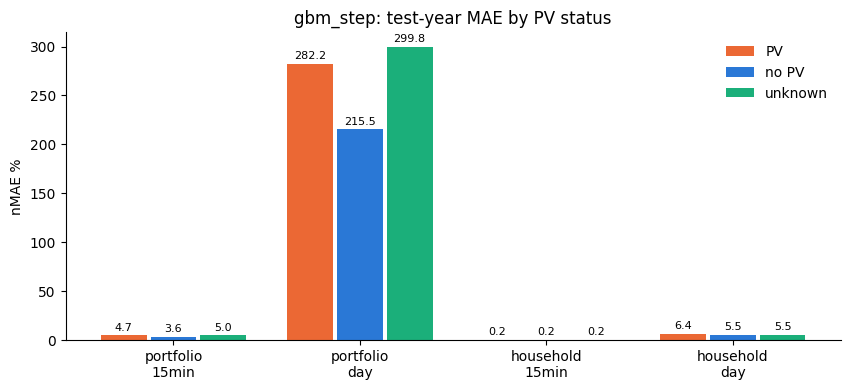

In [37]:
# Now when we evaluate the model in the test set, evaluate the performance for households with PV, without PV, and with unknown PV status
# Test-year performance per PV status: same levels as evaluate.evaluate, computed on each group's rows
from forecast import tuning

PV_GROUPS = {
    "PV": test["has_pv"] == 1,
    "no PV": test["has_pv"] == 0,
    "unknown": test["has_pv"].isna(),
}
GROUP_METRICS = ["MAE", "RMSE", "nMAE", "R2"]  # nMAE (%) to compare groups of different size

group_scores = {}
for group, mask in PV_GROUPS.items():
    rows = test[mask]
    group_pred = predictions.loc[rows.index, "prediction"]  # predictions was built from test: same row index
    group_scores[group] = tuning.score_rows(rows, group_pred)[GROUP_METRICS]
    print(f"{group:8s} {rows['Household_ID'].nunique():4d} households · {len(rows):,} test rows")

pv_table = pd.concat(group_scores, axis=1).round(3)
display(pv_table)

# nMAE per level and group (lower is better)
nmae = pd.DataFrame({group: s["MAE"] for group, s in group_scores.items()})
x = np.arange(len(nmae.index))
width = 0.8 / len(nmae.columns)
fig, ax = plt.subplots(figsize=(10, 4))
for i, (group, color) in enumerate(zip(nmae.columns, ["#eb6834", "#2a78d6", "#1baf7a"])):
    bars = ax.bar(x + (i - (len(nmae.columns) - 1) / 2) * width, nmae[group], width * 0.92, color=color, label=group)
    ax.bar_label(bars, fmt="%.1f", fontsize=8, padding=2)
ax.set(xticks=x, xticklabels=[lvl.replace("_", "\n") for lvl in nmae.index], ylabel="nMAE %",
       title=f"{NAME}: test-year MAE by PV status")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.show()


## 6. R² score

R² = 1 − Σ(actual − predicted)² / Σ(actual − mean actual)²: the share of the variation in consumption that the forecast explains. 1 is perfect, 0 is no better than always predicting the average, and below 0 is worse than that.

The bar chart compares R² of this model and the naive baselines at all four evaluation levels. The scatter plots show predicted vs actual portfolio consumption for this model: the closer the points lie to the dashed 1:1 line, the higher R².

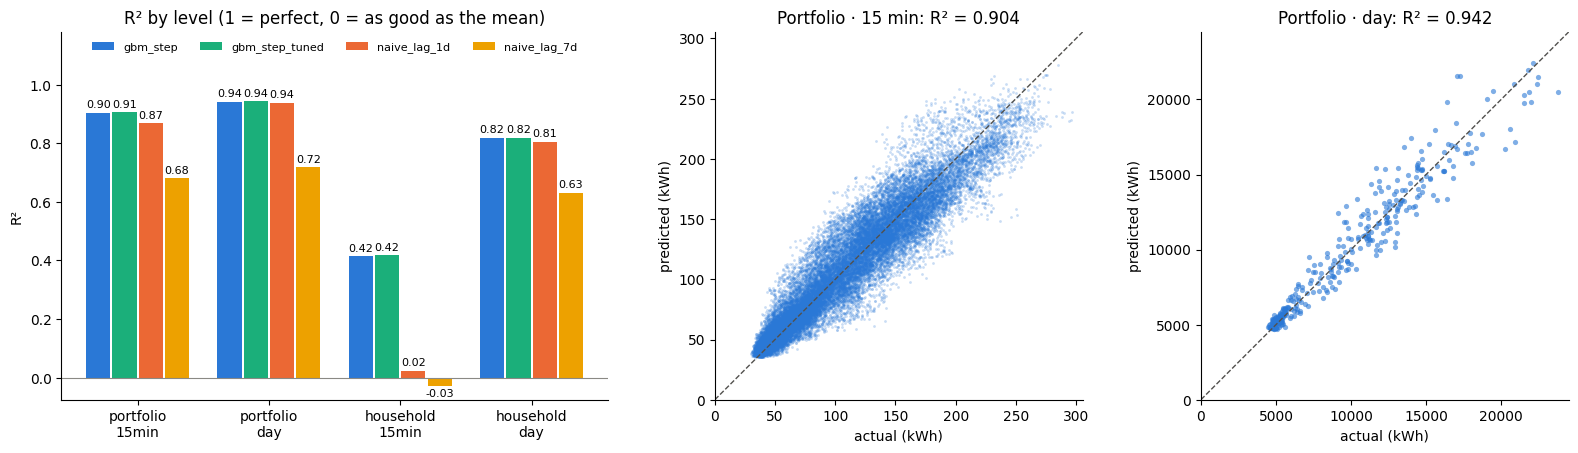

In [38]:
r2 = pd.DataFrame({name: s["R2"] for name, s in scores.items()})

# Portfolio sums of this model, for predicted-vs-actual
m = truth.merge(predictions, on=["Household_ID", "Timestamp"], how="left")
portfolio_15min = m.groupby("Timestamp")[["kwh", "prediction"]].sum()
portfolio_day = m.groupby(day.to_numpy())[["kwh", "prediction"]].sum()
portfolio_day = portfolio_day[portfolio_day["kwh"] > 0.5 * portfolio_day["kwh"].median()]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), width_ratios=[1.4, 1, 1])

# 1) R² per level and forecast
x = np.arange(len(r2.index))
width = 0.8 / len(r2.columns)
for i, (name, color) in enumerate(zip(r2.columns, COLORS)):
    bars = axes[0].bar(x + (i - (len(r2.columns) - 1) / 2) * width, r2[name], width * 0.92, color=color, label=name)
    axes[0].bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
axes[0].set(xticks=x, xticklabels=[lvl.replace("_", "\n") for lvl in r2.index], ylabel="R²",
            title="R² by level (1 = perfect, 0 = as good as the mean)")
axes[0].axhline(0, color="#8a8984", linewidth=0.8)
axes[0].set_ylim(top=max(1.0, r2.max().max()) * 1.18)  # room for the legend above the bars
axes[0].legend(frameon=False, fontsize=8, ncol=len(r2.columns), loc="upper center")

# 2) and 3) predicted vs actual, with the 1:1 line
panels = [("Portfolio · 15 min", "portfolio_15min", portfolio_15min),
          ("Portfolio · day", "portfolio_day", portfolio_day)]
for ax, (title, level, t) in zip(axes[1:], panels):
    many = len(t) > 1000
    ax.scatter(t["kwh"], t["prediction"], s=4 if many else 14, alpha=0.25 if many else 0.6,
               color=COLORS[0], linewidths=0)
    hi = max(t["kwh"].max(), t["prediction"].max()) * 1.03
    ax.plot([0, hi], [0, hi], color="#52514e", linewidth=1, linestyle="--")
    ax.set(xlim=(0, hi), ylim=(0, hi), aspect="equal", xlabel="actual (kWh)", ylabel="predicted (kWh)",
           title=f"{title}: R² = {r2.loc[level, NAME]:.3f}")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Feature Importance

,feature,mae_increase,mae_increase_std,contribution_pct
0,kwh_lag_1d,0.03141,0.00031,33.3
1,kwh_lag_7d,0.02336,0.00034,24.8
2,temperature_day_mean_1d,0.01094,0.00022,11.6
3,Survey_Building_LivingArea,0.00519,0.00014,5.5
4,quarter_hour,0.00439,0.00009,4.7
5,month,0.00367,0.00008,3.9
6,has_pv,0.00211,0.00009,2.2
7,temperature_1d,0.00202,0.00004,2.1
8,Survey_Building_Residents,0.00158,0.00003,1.7
9,Survey_HeatDistribution_System_Radiator,0.00156,0.00010,1.7


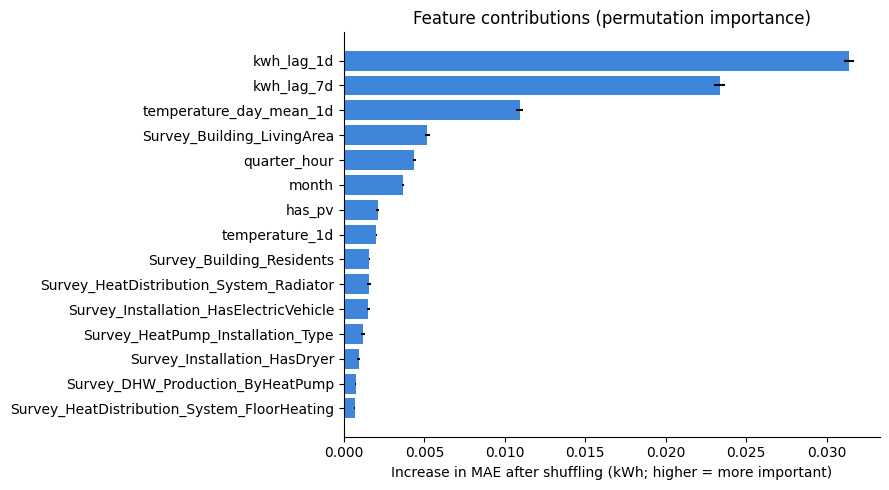

In [39]:
### 3.1 Feature contributions

#Permutation importance measures the increase in prediction MAE when one feature is shuffled. A larger increase means the fitted model relies more strongly on that feature. The calculation uses a reproducible sample to keep runtime manageable; it is diagnostic only and is not used to tune the model.

from sklearn.inspection import permutation_importance


def feature_contributions(estimator, frame, feature_names, *, sample_size=50_000,
                          n_repeats=5, random_state=0):
    """Return model-agnostic feature contributions based on permutation importance.

    ``mae_increase`` is the increase in kWh MAE after shuffling a feature.
    ``contribution_pct`` normalizes positive MAE increases to sum to 100%.
    The fitted estimator is never changed. ``frame`` must contain the target ``kwh``.
    """
    missing = [column for column in [*feature_names, "kwh"] if column not in frame]
    if missing:
        raise ValueError(f"frame is missing required columns: {missing}")
    if sample_size <= 0 or n_repeats <= 0:
        raise ValueError("sample_size and n_repeats must be positive")

    sample = frame.sample(n=min(sample_size, len(frame)), random_state=random_state)
    result = permutation_importance(
        estimator, sample[feature_names], sample["kwh"],
        scoring="neg_mean_absolute_error", n_repeats=n_repeats,
        random_state=random_state, n_jobs=-1,
    )
    table = pd.DataFrame({
        "feature": feature_names,
        "mae_increase": result.importances_mean,
        "mae_increase_std": result.importances_std,
    }).sort_values("mae_increase", ascending=False, ignore_index=True)
    positive = table["mae_increase"].clip(lower=0)
    total = positive.sum()
    table["contribution_pct"] = 100 * positive / total if total > 0 else 0.0
    return table


contributions = feature_contributions(model, test, FEATURES)
display(contributions.round({"mae_increase": 5, "mae_increase_std": 5, "contribution_pct": 1}))

top = contributions.head(15).sort_values("mae_increase")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top["feature"], top["mae_increase"], xerr=top["mae_increase_std"],
        color="#2a78d6", alpha=0.9)
ax.set(title="Feature contributions (permutation importance)",
       xlabel="Increase in MAE after shuffling (kWh; higher = more important)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Task 3 Uncertainty Evaluation

In [40]:
quantile_predictions = {}
for q in (0.1, 0.5, 0.75, 0.9):
    model = HistGradientBoostingRegressor(
        loss="quantile",
        quantile=q,
        max_iter=300,
        learning_rate=0.1,
        categorical_features="from_dtype",
        random_state=0,
    )
    model.fit(fit_rows[FEATURES], fit_rows["kwh"])
    quantile_predictions[q] = model.predict(val_rows[FEATURES]).clip(min=0)

lower, median, upper = (
    quantile_predictions[0.1],
    quantile_predictions[0.5],
    quantile_predictions[0.9],
)
coverage_80 = ((val_rows["kwh"] >= lower) & (val_rows["kwh"] <= upper)).mean()
mean_width = (upper - lower).mean()
print(f"80% interval coverage: {coverage_80:.1%}; mean width: {mean_width:.3f} kWh")

80% interval coverage: 78.1%; mean width: 0.774 kWh


In [41]:
check = val_rows[["quarter_hour", "has_pv"]].copy()
check["covered"] = (
    (val_rows["kwh"].to_numpy() >= lower)
    & (val_rows["kwh"].to_numpy() <= upper)
)
check["width"] = upper - lower

by_time = check.groupby("quarter_hour").agg(
    rows=("width", "size"),
    coverage=("covered", "mean"),
    mean_width=("width", "mean"),
)
by_pv = check.groupby("has_pv", dropna=False).agg(
    rows=("width", "size"),
    coverage=("covered", "mean"),
    mean_width=("width", "mean"),
)

display(by_time.sort_values("mean_width", ascending=False).head(10).round(3))
display(by_pv.round(3))

,rows,coverage,mean_width
quarter_hour,,,
10,19326,0.800,0.867
82,19326,0.812,0.866
81,19326,0.811,0.864
8,19326,0.802,0.863
0,19286,0.800,0.862
83,19326,0.818,0.859
84,19326,0.812,0.857
80,19326,0.811,0.856
9,19326,0.800,0.852


,rows,coverage,mean_width
has_pv,,,
0.0,507436,0.790,0.812
1.0,560980,0.759,0.762
NaN,786720,0.790,0.759


In [42]:
portfolio_val = pd.DataFrame(
    {
        "actual": val_rows["kwh"].to_numpy(),
        "q50": median,
        "q75": quantile_predictions[0.75],
    },
    index=val_rows["Timestamp"],
).groupby(level=0).sum()

under_cost, over_cost = 3.0, 1.0

for forecast in ("q50", "q75"):
    shortfall = (portfolio_val["actual"] - portfolio_val[forecast]).clip(lower=0)
    surplus = (portfolio_val[forecast] - portfolio_val["actual"]).clip(lower=0)
    mean_cost = (under_cost * shortfall + over_cost * surplus).mean()
    print(f"{forecast}: mean assumed cost per 15 min = {mean_cost:.2f}")

q50: mean assumed cost per 15 min = 79.08
q75: mean assumed cost per 15 min = 52.99


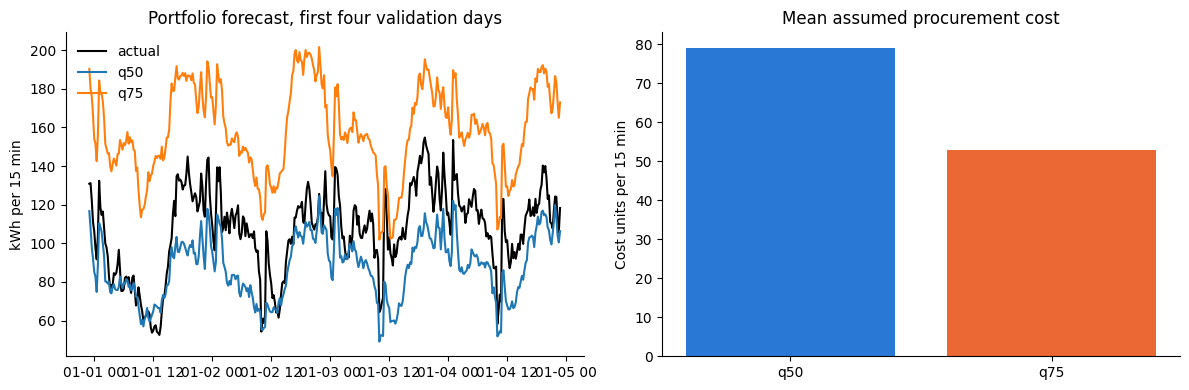

In [43]:
costs = {}
for name in ("q50", "q75"):
    shortfall = (portfolio_val["actual"] - portfolio_val[name]).clip(lower=0)
    surplus = (portfolio_val[name] - portfolio_val["actual"]).clip(lower=0)
    costs[name] = (3.0 * shortfall + surplus).mean()

view = portfolio_val.iloc[:96 * 4]  # first four validation days

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(view.index, view["actual"], color="black", label="actual")
axes[0].plot(view.index, view["q50"], label="q50")
axes[0].plot(view.index, view["q75"], label="q75")
axes[0].set(title="Portfolio forecast, first four validation days",
            ylabel="kWh per 15 min")
axes[0].legend(frameon=False)

axes[1].bar(["q50", "q75"], [costs["q50"], costs["q75"]],
            color=["#2a78d6", "#eb6834"])
axes[1].set(title="Mean assumed procurement cost",
            ylabel="Cost units per 15 min")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()